<a href="https://colab.research.google.com/github/Tahvia127/BUSN-20800-Final-Project-/blob/Vadim/notebooks/02_alignment_descriptive.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
tier1 = pd.read_parquet('tier1.parquet')
un_panel = pd.read_parquet('un_panel.parquet')
wb_sector = pd.read_parquet('wb_sector_year.parquet')

print('tier1:', tier1.shape)
print(tier1.columns.tolist())
print('\nun_panel:', un_panel.shape)
print(un_panel.columns.tolist())
print('\nwb_sector:', wb_sector.shape)
print(wb_sector.columns.tolist())

tier1: (26, 12)
['year', 'segment', 'n_meetings', 'n_tokens', 'sentiment', 'lex_development', 'lex_humanitarian', 'lex_climate', 'lex_gender', 'lex_conflict', 'lex_health', 'lex_governance']

un_panel: (244, 8)
['agency', 'year', 'revenue_usd', 'n_subagencies', 'rev_assessed_contributions', 'rev_revenue_from_other_activities', 'rev_voluntary_core_(un_earmarked)_contributions', 'rev_voluntary_non_core_(earmarked)_contributions']

wb_sector: (3375, 5)
['sector', 'year', 'totalamt_sum', 'grantamt_sum', 'project_count']


In [11]:
lex_cols = ['lex_development', 'lex_humanitarian', 'lex_climate',
            'lex_gender', 'lex_conflict', 'lex_health', 'lex_governance']
topic_by_year = tier1.set_index('year')[lex_cols]
un_rev = un_panel.pivot_table(index='year', columns='agency', values='revenue_usd')
topic_norm = topic_by_year.div(topic_by_year.sum(axis=1), axis=0)
un_norm = un_rev.div(un_rev.sum(axis=1), axis=0)

print('topic_norm shape:', topic_norm.shape)
print('un_norm shape:', un_norm.shape)
print(topic_norm.head(2))

topic_norm shape: (26, 7)
un_norm shape: (14, 19)
      lex_development  lex_humanitarian  lex_climate  lex_gender  \
year                                                               
2000         0.133929          0.089286     0.000000    0.005952   
2001         0.441866          0.131148     0.032787    0.051198   

      lex_conflict  lex_health  lex_governance  
year                                            
2000      0.172619    0.589286        0.008929  
2001      0.110719    0.150567        0.081715  


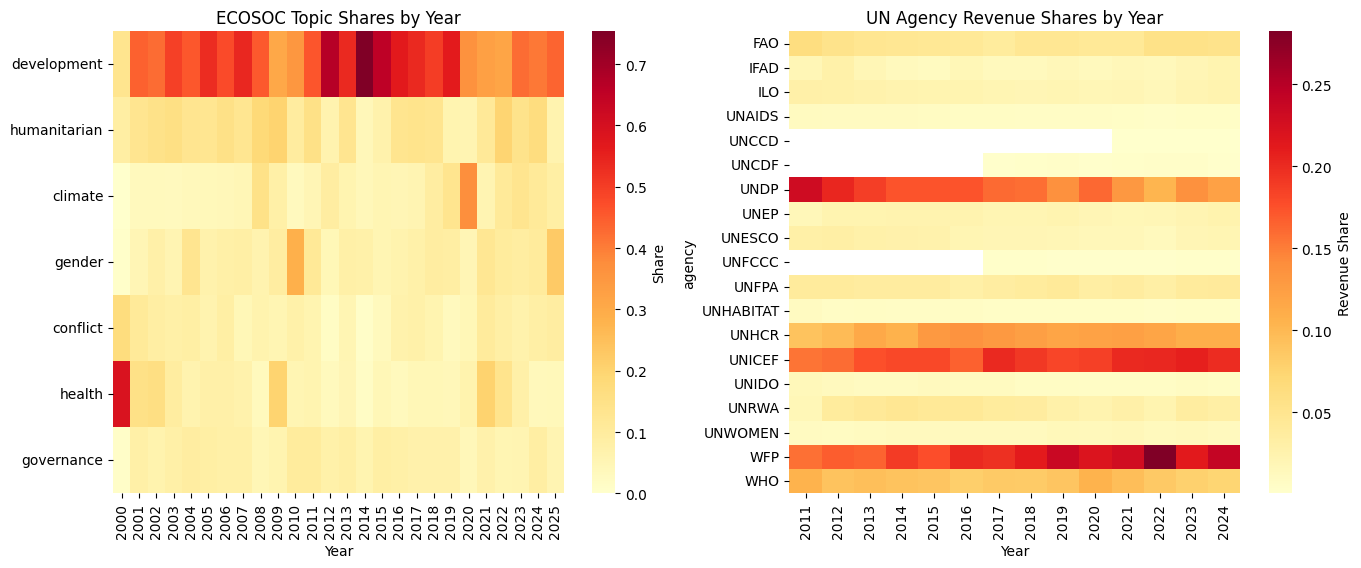

Saved fig1


In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(topic_norm.T, ax=ax1, cmap='YlOrRd',
            cbar_kws={'label': 'Share'},
            yticklabels=[c.replace('lex_', '') for c in lex_cols])
ax1.set_title('ECOSOC Topic Shares by Year')
ax1.set_xlabel('Year')

sns.heatmap(un_norm.T, ax=ax2, cmap='YlOrRd',
            cbar_kws={'label': 'Revenue Share'})
ax2.set_title('UN Agency Revenue Shares by Year')
ax2.set_xlabel('Year')

plt.savefig('fig1_topic_vs_un_revenue.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig1')

In [15]:
print(wb_sector.head(10))
print('\nUnique years:', sorted(wb_sector['year'].unique()))
print('\nNull % per sector:')
print(wb_pivot.isna().mean().sort_values())

                          sector    year  totalamt_sum  grantamt_sum  \
0  (Historic)Agricultural credit  1967.0           0.0           0.0   
1  (Historic)Agricultural credit  1968.0           0.0           0.0   
2  (Historic)Agricultural credit  1969.0           0.0           0.0   
3  (Historic)Agricultural credit  1970.0           0.0           0.0   
4  (Historic)Agricultural credit  1971.0           0.0           0.0   
5  (Historic)Agricultural credit  1972.0           0.0           0.0   
6  (Historic)Agricultural credit  1973.0           0.0           0.0   
7  (Historic)Agricultural credit  1974.0           0.0           0.0   
8  (Historic)Agricultural credit  1975.0           0.0           0.0   
9  (Historic)Agricultural credit  1976.0           0.0           0.0   

   project_count  
0              1  
1              1  
2              4  
3              7  
4              5  
5              6  
6              8  
7              5  
8              5  
9              9 

In [16]:
wb_sector['year'] = wb_sector['year'].astype(int)
wb_pivot = wb_sector[wb_sector['year'] >= 2000].pivot_table(
    index='year', columns='sector', values='totalamt_sum'
)

top_sectors = wb_sector[wb_sector['year'] >= 2000].groupby('sector')['totalamt_sum'].sum().nlargest(8).index
wb_pivot = wb_pivot[top_sectors]

wb_norm = wb_pivot.div(wb_pivot.sum(axis=1), axis=0)

common_years = topic_norm.index.intersection(wb_norm.index)
topic_wb = topic_norm.loc[common_years]
wb_wb = wb_norm.loc[common_years]

print('Common years:', len(common_years))
print('WB sectors:', wb_wb.columns.tolist())
print(wb_wb.head(2))

Common years: 25
WB sectors: ['Adult, Basic and Continuing Education', 'Agricultural Extension, Research, and Other Support Activities', 'Agricultural markets, commercialization and agri-business', 'Agro-industry', 'Aviation', 'Banking Institutions', 'Capital Markets', 'Central Government (Central Agencies)']
sector  Adult, Basic and Continuing Education  \
year                                            
2000                                      NaN   
2001                                      NaN   

sector  Agricultural Extension, Research, and Other Support Activities  \
year                                                                     
2000                                                  NaN                
2001                                                  NaN                

sector  Agricultural markets, commercialization and agri-business  \
year                                                                
2000                                                  NaN

In [17]:
wb_2000 = wb_sector[wb_sector['year'] >= 2000]
print(wb_2000.groupby('year')['totalamt_sum'].sum().head(10))
print('\nZero values:', (wb_2000['totalamt_sum'] == 0).sum())
print('Null values:', wb_2000['totalamt_sum'].isna().sum())
print('\nTop sectors by total:')
print(wb_2000.groupby('sector')['totalamt_sum'].sum().nlargest(8))

year
2000    0.0
2001    0.0
2002    0.0
2003    0.0
2004    0.0
2005    0.0
2006    0.0
2007    0.0
2008    0.0
2009    0.0
Name: totalamt_sum, dtype: float64

Zero values: 1516
Null values: 0

Top sectors by total:
sector
Adult, Basic and Continuing Education                             0.0
Agricultural Extension, Research, and Other Support Activities    0.0
Agricultural markets, commercialization and agri-business         0.0
Agro-industry                                                     0.0
Aviation                                                          0.0
Banking Institutions                                              0.0
Capital Markets                                                   0.0
Central Government (Central Agencies)                             0.0
Name: totalamt_sum, dtype: float64


In [18]:
print(wb_sector[wb_sector['year'] >= 2000].groupby('year')['grantamt_sum'].sum().head(10))
print('\nTop sectors by grant total:')
print(wb_sector[wb_sector['year'] >= 2000].groupby('sector')['grantamt_sum'].sum().nlargest(8))

year
2000    0.0
2001    0.0
2002    0.0
2003    0.0
2004    0.0
2005    0.0
2006    0.0
2007    0.0
2008    0.0
2009    0.0
Name: grantamt_sum, dtype: float64

Top sectors by grant total:
sector
Adult, Basic and Continuing Education                             0.0
Agricultural Extension, Research, and Other Support Activities    0.0
Agricultural markets, commercialization and agri-business         0.0
Agro-industry                                                     0.0
Aviation                                                          0.0
Banking Institutions                                              0.0
Capital Markets                                                   0.0
Central Government (Central Agencies)                             0.0
Name: grantamt_sum, dtype: float64


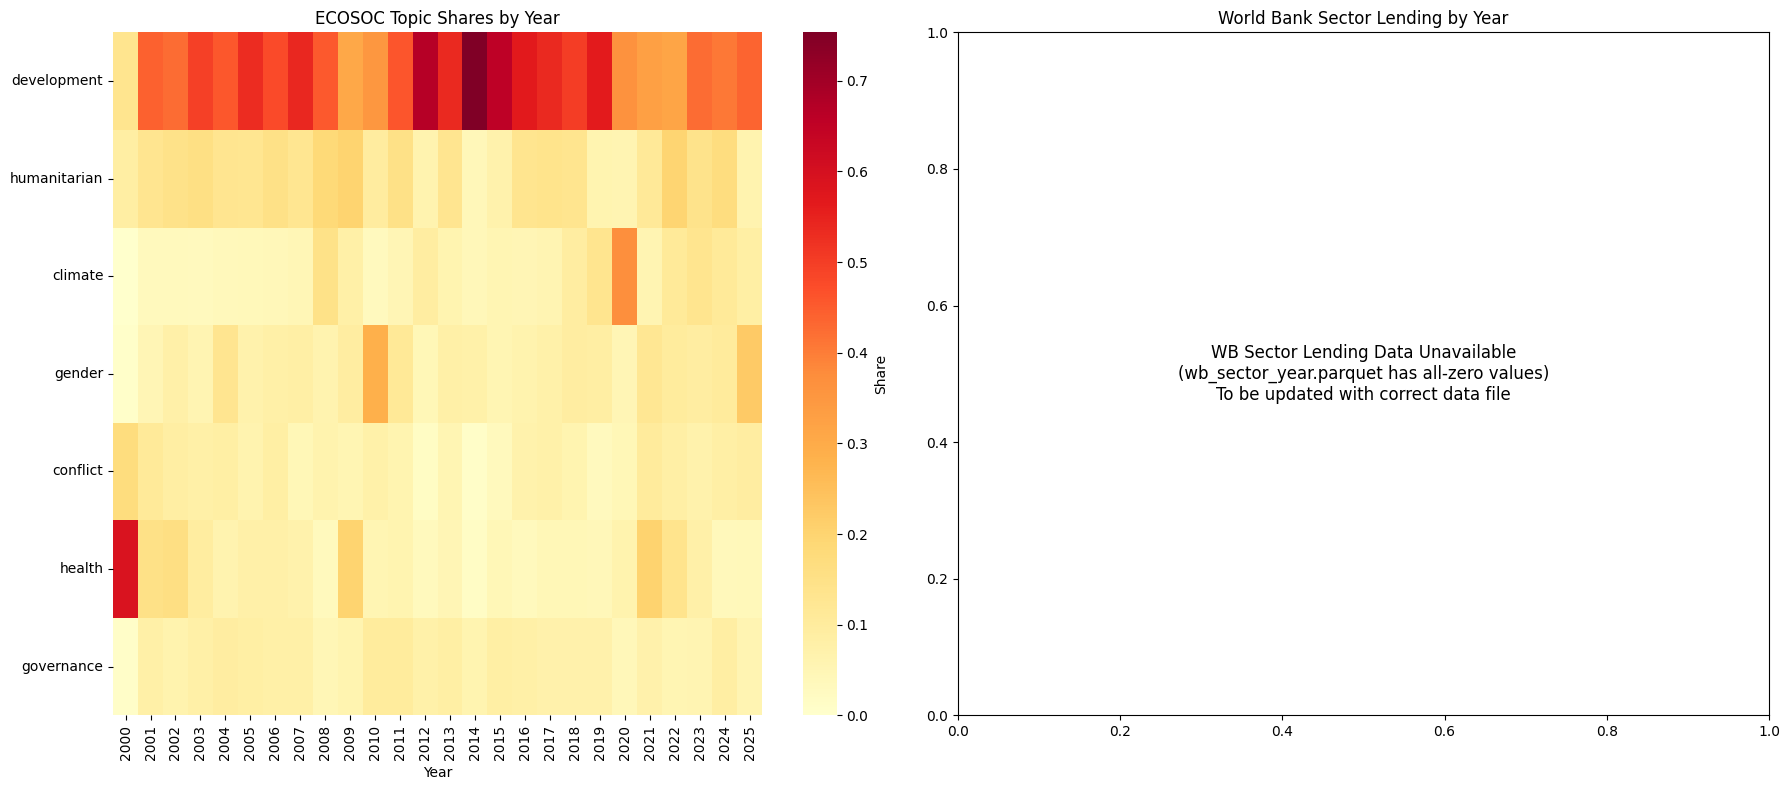

Saved fig2


In [19]:
# NOTE: wb_sector_year.parquet has all-zero values for totalamt_sum and grantamt_sum
# for years 2000+. Right panel will be updated once correct WB sector data is provided.

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# Panel 1: Topic shares (working)
sns.heatmap(topic_norm.T, ax=ax1, cmap='YlOrRd',
            cbar_kws={'label': 'Share'},
            yticklabels=[c.replace('lex_', '') for c in lex_cols])
ax1.set_title('ECOSOC Topic Shares by Year')
ax1.set_xlabel('Year')

# Panel 2: WB sector lending (placeholder - data unavailable)
ax2.text(0.5, 0.5, 'WB Sector Lending Data Unavailable\n(wb_sector_year.parquet has all-zero values)\nTo be updated with correct data file',
         ha='center', va='center', transform=ax2.transAxes, fontsize=12)
ax2.set_title('World Bank Sector Lending by Year')

plt.tight_layout()
plt.savefig('fig2_topic_vs_wb_sectors.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig2')

In [20]:
!pip install umap-learn -q

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


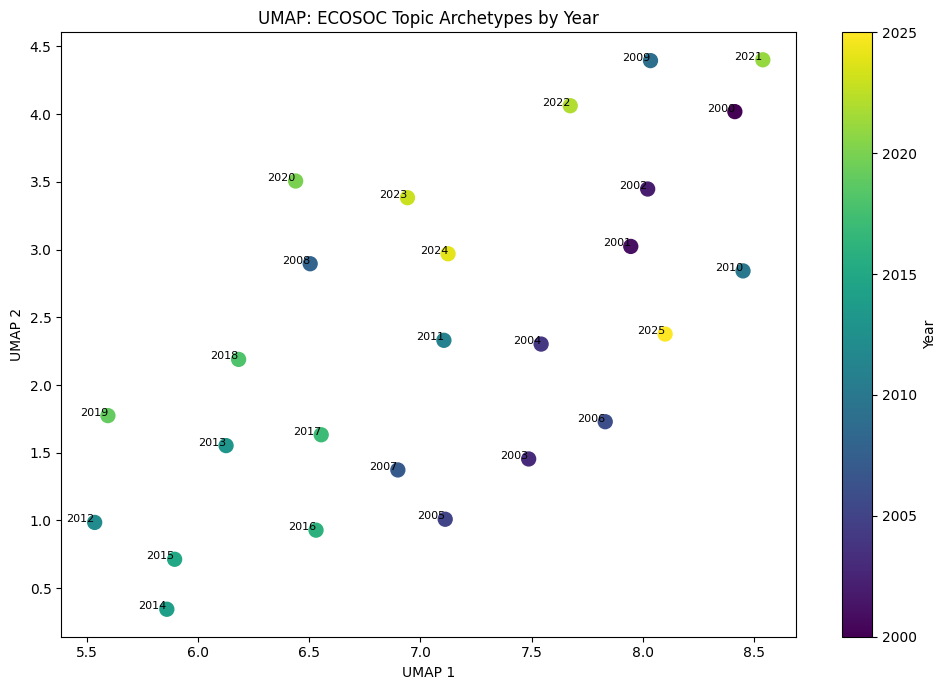

Saved fig3


In [21]:
import umap
import numpy as np

X = topic_norm.fillna(0).values
years = topic_norm.index.tolist()

reducer = umap.UMAP(n_components=2, random_state=42)
embedding = reducer.fit_transform(X)

fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(embedding[:, 0], embedding[:, 1],
                     c=years, cmap='viridis', s=100)
plt.colorbar(scatter, ax=ax, label='Year')

for i, year in enumerate(years):
    ax.annotate(str(year), (embedding[i, 0], embedding[i, 1]),
                fontsize=8, ha='right')

ax.set_title('UMAP: ECOSOC Topic Archetypes by Year')
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')

plt.tight_layout()
plt.savefig('fig3_umap_archetypes.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig3')